# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.mlflow_utils import get_latest_run_dir

RUN_DIR = get_latest_run_dir(target="POINT_TOTAL", experiment_name="point_total_regression")


MODEL_KEY = "xgb_calibrated"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

,pivot,prob_under,prob_over
0,218.5,0.735351,0.264649
1,219.5,0.750364,0.249636
2,220.5,0.765138,0.234862
3,221.5,0.779661,0.220339
4,222.5,0.793916,0.206084


,prediction,actual,sigma,pivot,prob_under,prob_over,actual_over,pred_over
0,211.02489,235,8.814236,230.5,0.986430,1.356971e-02,1,1.356971e-02
1,210.40549,222,10.178494,235.5,0.993158,6.842166e-03,0,6.842166e-03
2,203.46340,204,7.878082,231.5,0.999814,1.862685e-04,0,1.862685e-04
3,214.97250,219,8.537378,233.5,0.985003,1.499728e-02,0,1.499728e-02
4,180.00711,195,10.534489,233.5,1.000000,1.908329e-07,0,1.908329e-07


## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.364865,0.278838,74
1,219.5,0.208333,0.199201,72
2,220.5,0.276316,0.252556,76
3,221.5,0.172414,0.207977,58
4,222.5,0.270270,0.153662,74
5,223.5,0.108108,0.151164,74
6,224.5,0.242857,0.165694,70
7,225.5,0.222222,0.139811,81
8,226.5,0.146667,0.145390,75
9,227.5,0.207792,0.149516,77


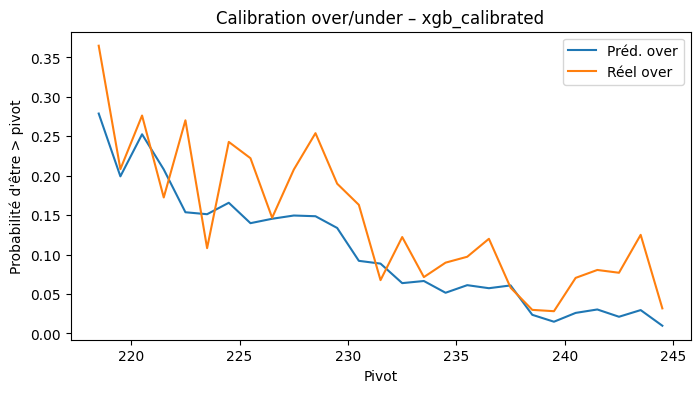

In [2]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [3]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
633,175.55400,148,239.5,0.0,1.0,0.5,True
1632,174.83876,190,235.5,0.0,1.0,0.5,True
805,176.43298,189,231.5,0.0,1.0,0.5,True
1872,170.83221,163,234.5,0.0,1.0,0.5,True
783,180.86812,191,243.5,0.0,1.0,0.5,True
1261,180.62300,150,237.5,0.0,1.0,0.5,True
1412,179.63410,189,240.5,0.0,1.0,0.5,True
1176,177.17635,160,240.5,0.0,1.0,0.5,True
1820,179.13669,179,241.5,0.0,1.0,0.5,True
271,161.56912,182,244.5,0.0,1.0,0.5,True


## Pivot bins (2 pts)

/tmp/ipykernel_2502447/906336297.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 221.5)",222,0.283784,0.244012
1,"[221.5, 224.5)",206,0.184466,0.168057
2,"[224.5, 227.5)",226,0.203540,0.149679
3,"[227.5, 230.5)",219,0.214612,0.143559
4,"[230.5, 233.5)",256,0.121094,0.081077
5,"[233.5, 236.5)",234,0.085470,0.059866
6,"[236.5, 239.5)",211,0.071090,0.047766
7,"[239.5, 242.5)",229,0.061135,0.024190
8,"[242.5, 245.5)",197,0.076142,0.019886


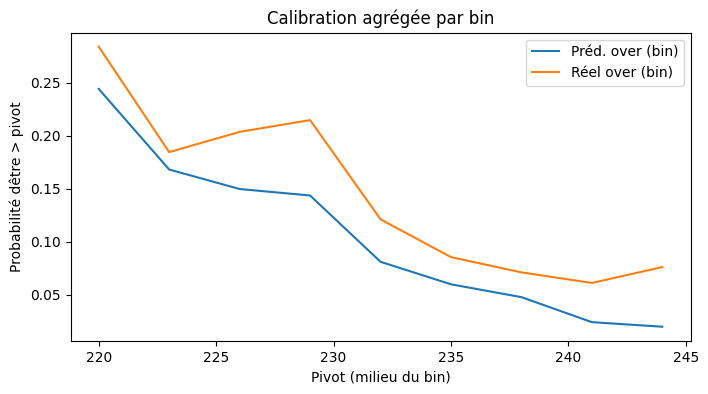

In [ ]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=2, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [8]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,1956,0.879857
1,0.10,1913,0.889179
2,0.15,1883,0.895380
3,0.20,1849,0.901028
4,0.25,1805,0.906371


## Distribution des sigma

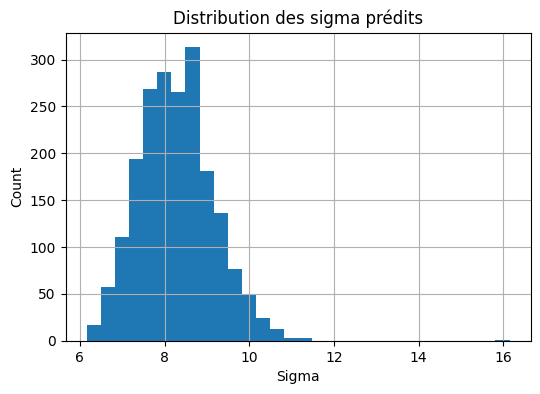

In [9]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
